# Analyse des Cristalliseurs - Projet IBM REJU

## Objectif du Projet
Ce notebook présente une analyse complète des données des cristalliseurs de l'entreprise. L'objectif est de:
- Prétraiter et nettoyer les données des campagnes 5, 6 et 7
- Comparer les performances des 3 cristalliseurs
- Identifier des patterns et anomalies
- Appliquer des techniques de clustering pour segmenter les comportements
- Visualiser les tendances temporelles avec incrémentation



---
## 1. Configuration et Imports

In [43]:
# Imports standards
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Imports pour le Machine Learning
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

# Création des dossiers de sortie
import os
os.makedirs('outputs/figures', exist_ok=True)
os.makedirs('outputs/data', exist_ok=True)
os.makedirs('outputs/reports', exist_ok=True)

print('✓ Configuration terminée')
print(f'Date d\'exécution: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

✓ Configuration terminée
Date d'exécution: 2026-03-06 13:04:43


---
## 2. Chargement des Données

In [44]:
# Chargement du mapping des instruments
mapping_df = pd.read_excel('826-Crystallizer Mapping-TEN-Officiel.xlsx', sheet_name='826')
print('=== Mapping des Instruments ===')
print(mapping_df.head(10))
print(f'\nNombre total d\'instruments: {len(mapping_df)}')

=== Mapping des Instruments ===
  Equipement Type Equipement TAG IG Instrument TAG ID  \
0      Common 826               NaN          826FQR23   
1      Common 826               NaN       826FQR23_Zh   
2  CRYSTALLIZER 1        U-82601-01        826P-82601   
3  CRYSTALLIZER 1        U-82601-01           826XV16   
4  CRYSTALLIZER 1        U-82601-01          826SRK02   
5  CRYSTALLIZER 1        U-82601-01           826XV01   
6  CRYSTALLIZER 1        U-82601-01          826TRC07   
7  CRYSTALLIZER 1        U-82601-01   826TRC07_DeltaT   
8  CRYSTALLIZER 1        U-82601-01           826LR04   
9  CRYSTALLIZER 1        U-82601-01           826SP01   

                       Instrument Description  
0       Feed flow meter for all crystallizers  
1  Integration over flow rate, therefore mass  
2      Slurry transfer pump, operating sensor  
3                          3-way supply valve  
4                              Agitator speed  
5            Crystallizer bottom on/off valve  
6   

In [30]:
# Fonction d'harmonisation des noms de colonnes
def harmonize_columns(df):
    '''Harmonise les noms de colonnes en ajoutant le préfixe AVG_ si nécessaire'''
    rename_map = {}
    for col in df.columns:
        # Ajouter AVG_ aux colonnes qui commencent par 826 mais n'ont pas de préfixe
        if col.startswith('826') and not any(col.startswith(prefix) for prefix in ['AVG_', 'MIN_', 'MAX_', 'STDDEV_']):
            rename_map[col] = f'AVG_{col}'
    
    if rename_map:
        print(f'  → Harmonisation: {len(rename_map)} colonnes renommées')
    return df.rename(columns=rename_map)

# Chargement des données des campagnes
print('\n=== Chargement des Données des Campagnes ===')

# Campagne 5
campaign5_hour = pd.read_csv('T826_CRYSTALLIZER_CAMPAIGN_5_PIVOTBYHOUR.csv')
campaign5_hour = harmonize_columns(campaign5_hour)
campaign5_hour['CAMPAIGN'] = 'Campaign_5'
print(f'✓ Campagne 5 (par heure): {campaign5_hour.shape}')

# Campagne 6
campaign6_hour = pd.read_csv('T826_CRYSTALLIZER_CAMPAIGN_6_PIVOTBYHOUR.csv')
campaign6_hour = harmonize_columns(campaign6_hour)
campaign6_hour['CAMPAIGN'] = 'Campaign_6'
print(f'✓ Campagne 6 (par heure): {campaign6_hour.shape}')

# Campagne 7
campaign7_hour = pd.read_csv('T826_CRYSTALLIZER_CAMPAIGN_7_PIVOT.csv')
campaign7_hour = harmonize_columns(campaign7_hour)
campaign7_hour['CAMPAIGN'] = 'Campaign_7'
print(f'✓ Campagne 7 (par heure): {campaign7_hour.shape}')

# Aperçu
print('\n=== Aperçu des données (Campagne 5) ===')
display(campaign5_hour.head())

# Vérifier les colonnes disponibles
print('\n=== Colonnes Harmonisées Disponibles ===')
temp_cols_available = [col for col in campaign5_hour.columns if 'TRC' in col and 'AVG' in col and 'DELTAT' not in col]
level_cols_available = [col for col in campaign5_hour.columns if 'LR' in col and 'AVG' in col]
print(f'Températures: {temp_cols_available}')
print(f'Niveaux: {level_cols_available}')


=== Chargement des Données des Campagnes ===
✓ Campagne 5 (par heure): (374, 58)
✓ Campagne 6 (par heure): (464, 58)
  → Harmonisation: 13 colonnes renommées
✓ Campagne 7 (par heure): (852471, 16)

=== Aperçu des données (Campagne 5) ===


,INSTRUMENT_TAG_TS,MIN_826TRC07_DELTAT,MIN_826LR05,MIN_826TRC09_DELTAT,MIN_826TRC08_DELTAT,MIN_826LR06,MIN_826FQR23,MIN_826TRC08,MIN_826TRC07,MIN_826TRC09,...,STDDEV_826FQR23,STDDEV_826TRC08,STDDEV_826TRC07,STDDEV_826TRC09,STDDEV_P_82601,STDDEV_826XV16,STDDEV_826XV01,STDDEV_826XV18,STDDEV_826XV14,CAMPAIGN
0,2025-08-27 11,0.0,-0.04,0.0,0.0,1.07,-5.07,25.72,25.93,25.45,...,0.188561,0.046086,0.041713,0.045444,NaN,NaN,NaN,NaN,NaN,Campaign_5
1,2025-08-27 12,0.0,-0.04,0.0,0.0,1.02,-5.05,25.87,26.08,25.60,...,0.221326,0.050571,0.047159,0.051719,NaN,NaN,NaN,NaN,NaN,Campaign_5
2,2025-08-27 13,0.0,-0.04,0.0,0.0,0.98,-4.97,26.04,26.25,25.78,...,0.214088,0.053797,0.053591,0.054925,NaN,NaN,NaN,NaN,NaN,Campaign_5
3,2025-08-27 14,0.0,-0.04,0.0,0.0,0.97,-5.00,26.23,26.44,25.98,...,0.214167,0.057188,0.060309,0.060287,NaN,NaN,NaN,NaN,NaN,Campaign_5
4,2025-08-27 15,0.0,-0.04,0.0,0.0,0.94,-5.19,26.43,26.64,26.18,...,0.232932,0.059160,0.059814,0.060064,NaN,NaN,NaN,NaN,NaN,Campaign_5



=== Colonnes Harmonisées Disponibles ===
Températures: ['AVG_826TRC08', 'AVG_826TRC07', 'AVG_826TRC09']
Niveaux: ['AVG_826LR05', 'AVG_826LR06']


---
## 3. Preprocessing et Nettoyage des Données

In [31]:
def preprocess_campaign_data(df, campaign_name):
    df_clean = df.copy()
    
    # Conversion du timestamp
    if 'INSTRUMENT_TAG_TS' in df_clean.columns:
        df_clean['TIMESTAMP'] = pd.to_datetime(df_clean['INSTRUMENT_TAG_TS'])
        df_clean = df_clean.sort_values('TIMESTAMP')
    
    # Statistiques des valeurs manquantes
    print(f'\n=== {campaign_name} - Valeurs Manquantes ===')
    missing_stats = df_clean.isnull().sum()
    missing_pct = (missing_stats / len(df_clean)) * 100
    missing_df = pd.DataFrame({
        'Missing_Count': missing_stats,
        'Missing_Percentage': missing_pct
    }).sort_values('Missing_Percentage', ascending=False)
    print(missing_df[missing_df['Missing_Count'] > 0].head(10))
    
    return df_clean

# Prétraitement
campaign5_clean = preprocess_campaign_data(campaign5_hour, 'Campaign 5')
campaign6_clean = preprocess_campaign_data(campaign6_hour, 'Campaign 6')
campaign7_clean = preprocess_campaign_data(campaign7_hour, 'Campaign 7')

# Consolidation
all_campaigns = pd.concat([campaign5_clean, campaign6_clean, campaign7_clean], ignore_index=True)
print(f'\n=== Données Consolidées ===')
print(f'Total de lignes: {len(all_campaigns)}')
print(f'Répartition par campagne:')
print(all_campaigns['CAMPAIGN'].value_counts())


=== Campaign 5 - Valeurs Manquantes ===
                Missing_Count  Missing_Percentage
MIN_826XV14               365           97.593583
MAX_826XV14               365           97.593583
AVG_826XV14               365           97.593583
STDDEV_826XV14            365           97.593583
AVG_826XV01               360           96.256684
STDDEV_826XV18            360           96.256684
MAX_826XV18               360           96.256684
MAX_826XV01               360           96.256684
STDDEV_826XV01            360           96.256684
MIN_826XV01               360           96.256684

=== Campaign 6 - Valeurs Manquantes ===
                Missing_Count  Missing_Percentage
MIN_826XV14               458           98.706897
MAX_826XV14               458           98.706897
AVG_826XV14               458           98.706897
STDDEV_826XV14            458           98.706897
AVG_826XV01               456           98.275862
STDDEV_826XV18            456           98.275862
MAX_826XV18       

---
## 4. Analyse Exploratoire (EDA)

In [32]:
# Statistiques descriptives
numeric_cols = all_campaigns.select_dtypes(include=[np.number]).columns.tolist()
print('=== Statistiques Descriptives ===')
display(all_campaigns[numeric_cols].describe())

=== Statistiques Descriptives ===


,MIN_826TRC07_DELTAT,MIN_826LR05,MIN_826TRC09_DELTAT,MIN_826TRC08_DELTAT,MIN_826LR06,MIN_826FQR23,MIN_826TRC08,MIN_826TRC07,MIN_826TRC09,MIN_P_82601,...,STDDEV_826TRC09,STDDEV_P_82601,STDDEV_826XV16,STDDEV_826XV01,STDDEV_826XV18,STDDEV_826XV14,AVG_826TRC07_DeltaT,AVG_826TRC09_DeltaT,AVG_826TRC08_DeltaT,P-82601
count,838.000000,838.000000,838.000000,838.000000,838.000000,838.000000,837.000000,837.000000,837.000000,49.000000,...,837.000000,49.000000,30.000000,22.000000,22.000000,15.000000,852011.000000,852010.000000,852010.000000,37.000000
mean,-0.050358,7.781086,-0.050943,-0.035036,21.919642,-83.955084,35.356105,36.418411,36.683692,0.040816,...,0.450744,0.574988,0.185193,0.457179,0.328015,0.471405,0.000773,0.000469,0.002593,0.486486
std,0.179005,21.318078,0.194649,0.138249,31.958695,759.870190,21.818200,21.784092,21.774427,0.199915,...,1.143577,0.245156,0.289933,0.323795,0.339373,0.345033,0.159230,0.085890,0.089687,0.506712
min,-2.720000,-0.040000,-2.230000,-2.030000,-118.520000,-15463.010000,14.370000,12.380000,13.310000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.790000,-0.830000,-0.820000,0.000000
25%,-0.040000,-0.040000,-0.040000,-0.020000,-0.030000,-9.470000,21.420000,23.490000,22.540000,0.000000,...,0.032923,0.577350,0.000000,0.000000,0.000000,0.000000,-0.010000,0.000000,0.000000,0.000000
50%,-0.010000,-0.040000,-0.010000,0.000000,-0.030000,-8.895000,23.970000,24.900000,26.670000,0.000000,...,0.097649,0.707107,0.000000,0.642229,0.267261,0.707107,0.000000,0.000000,0.000000,0.000000
75%,0.000000,-0.030000,0.000000,0.000000,32.880000,-7.500000,39.230000,39.700000,51.820000,0.000000,...,0.276265,0.707107,0.569943,0.707107,0.707107,0.707107,0.010000,0.010000,0.000000,1.000000
max,0.170000,77.980000,0.210000,0.200000,96.610000,292.660000,81.830000,83.170000,98.170000,1.000000,...,13.439540,0.707107,0.707107,0.707107,0.707107,0.707107,6.930000,3.000000,4.270000,1.000000


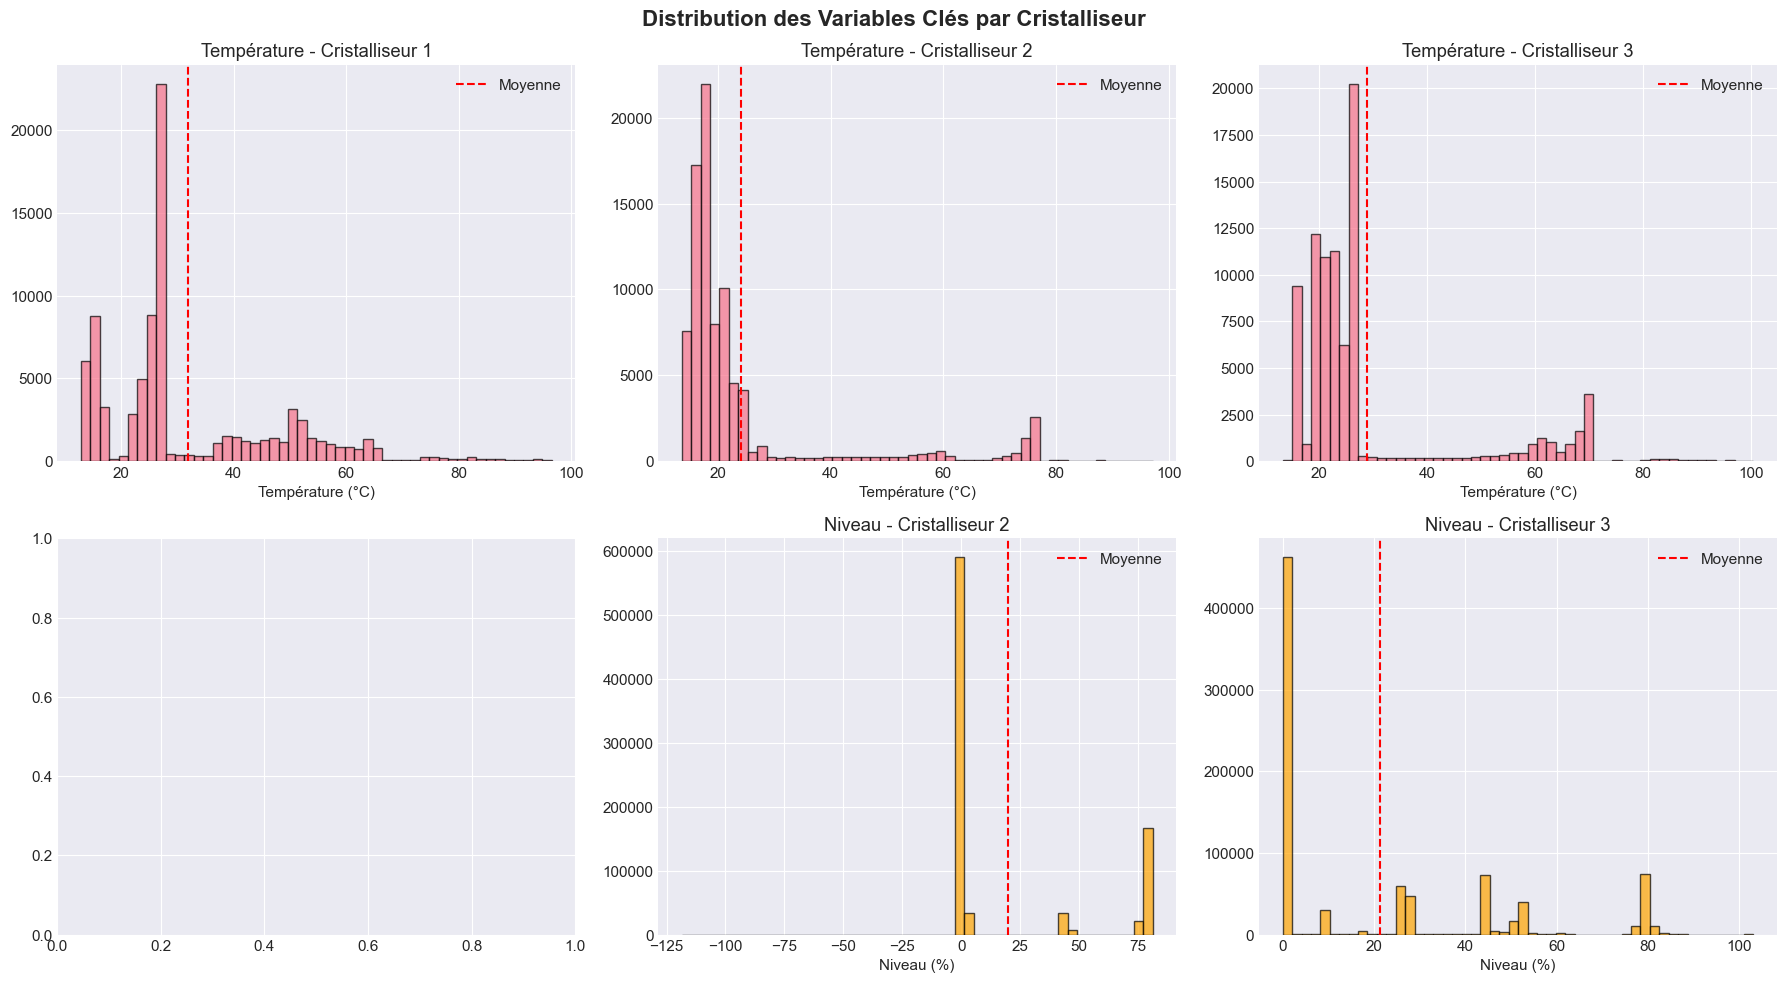

✓ Graphique sauvegardé


In [33]:
# Distribution des variables clés
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribution des Variables Clés par Cristalliseur', fontsize=16, fontweight='bold')

# Températures
temp_cols = ['AVG_826TRC07', 'AVG_826TRC08', 'AVG_826TRC09']
for idx, col in enumerate(temp_cols):
    if col in all_campaigns.columns:
        axes[0, idx].hist(all_campaigns[col].dropna(), bins=50, alpha=0.7, edgecolor='black')
        axes[0, idx].set_title(f'Température - Cristalliseur {idx+1}')
        axes[0, idx].set_xlabel('Température (°C)')
        axes[0, idx].axvline(all_campaigns[col].mean(), color='red', linestyle='--', label='Moyenne')
        axes[0, idx].legend()

# Niveaux
level_cols = ['AVG_826LR04', 'AVG_826LR05', 'AVG_826LR06']
for idx, col in enumerate(level_cols):
    if col in all_campaigns.columns:
        axes[1, idx].hist(all_campaigns[col].dropna(), bins=50, alpha=0.7, edgecolor='black', color='orange')
        axes[1, idx].set_title(f'Niveau - Cristalliseur {idx+1}')
        axes[1, idx].set_xlabel('Niveau (%)')
        axes[1, idx].axvline(all_campaigns[col].mean(), color='red', linestyle='--', label='Moyenne')
        axes[1, idx].legend()

plt.tight_layout()
plt.savefig('outputs/figures/01_distributions_variables_cles.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Graphique sauvegardé')

---
## 5. Comparaison des Cristalliseurs avec Incrémentation

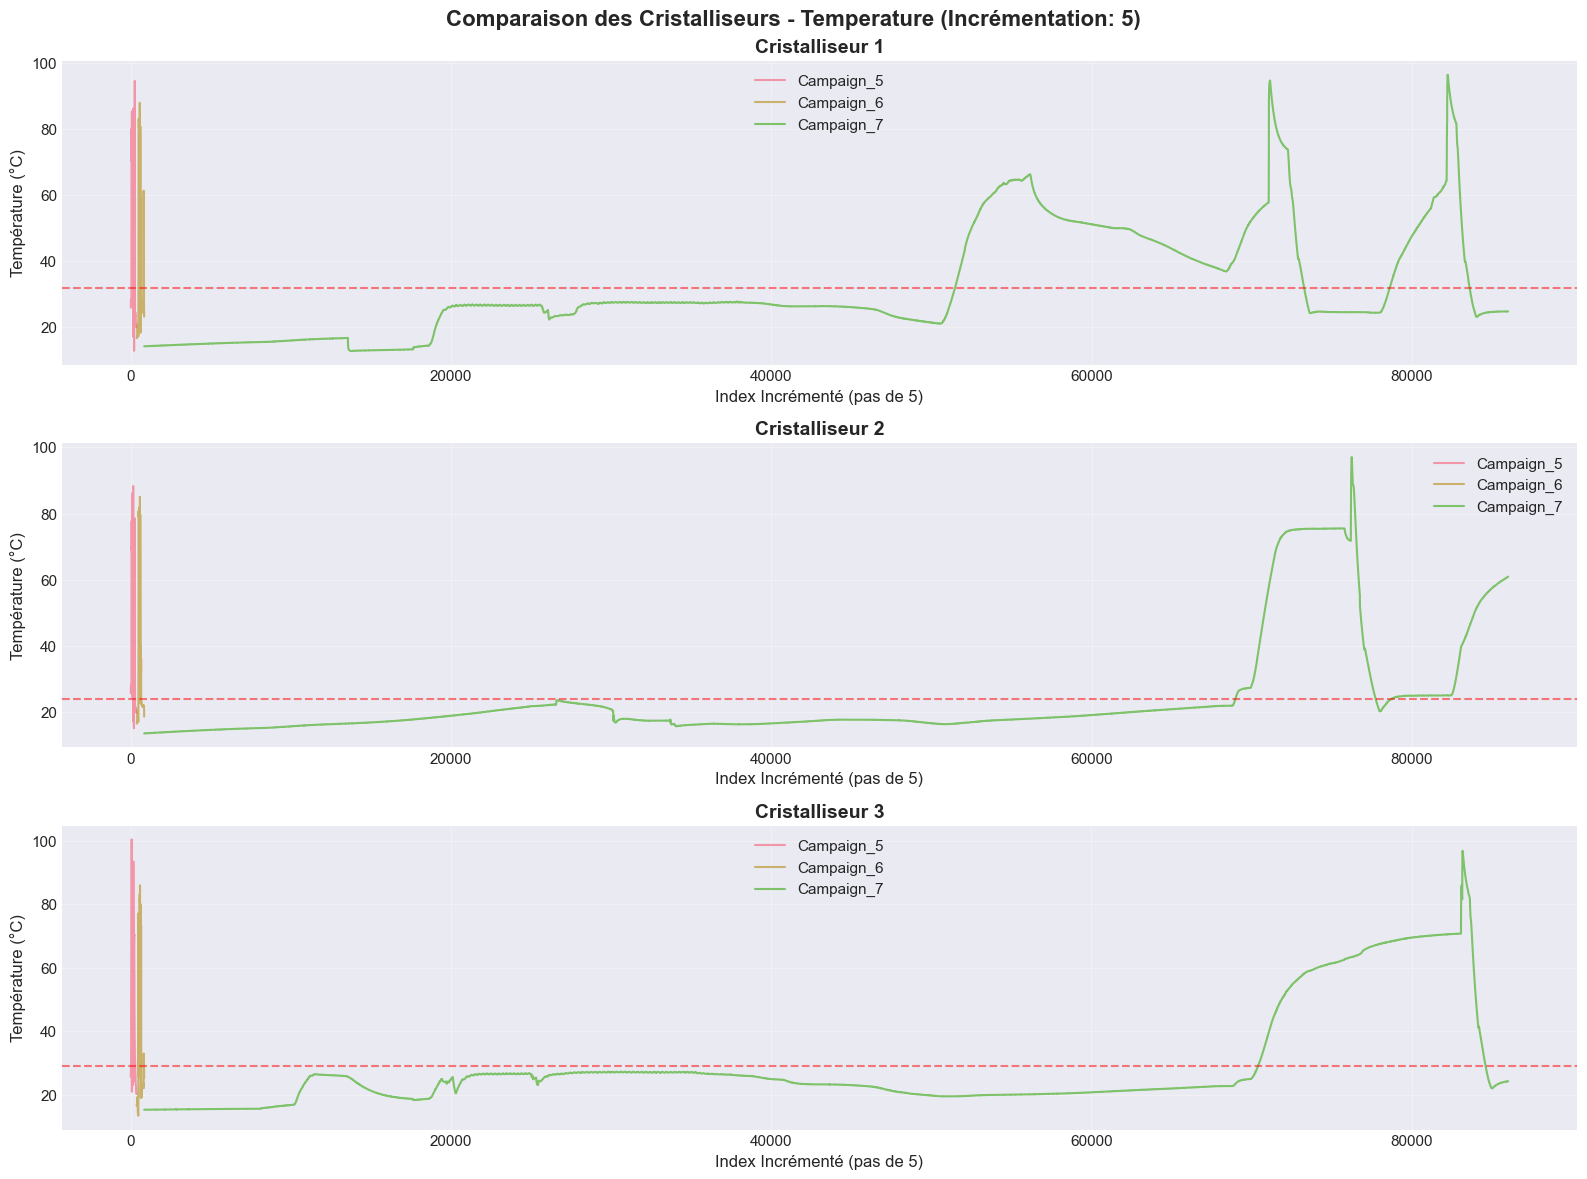

✓ Graphique sauvegardé: outputs/figures/02_comparison_temperature_increment_5.png


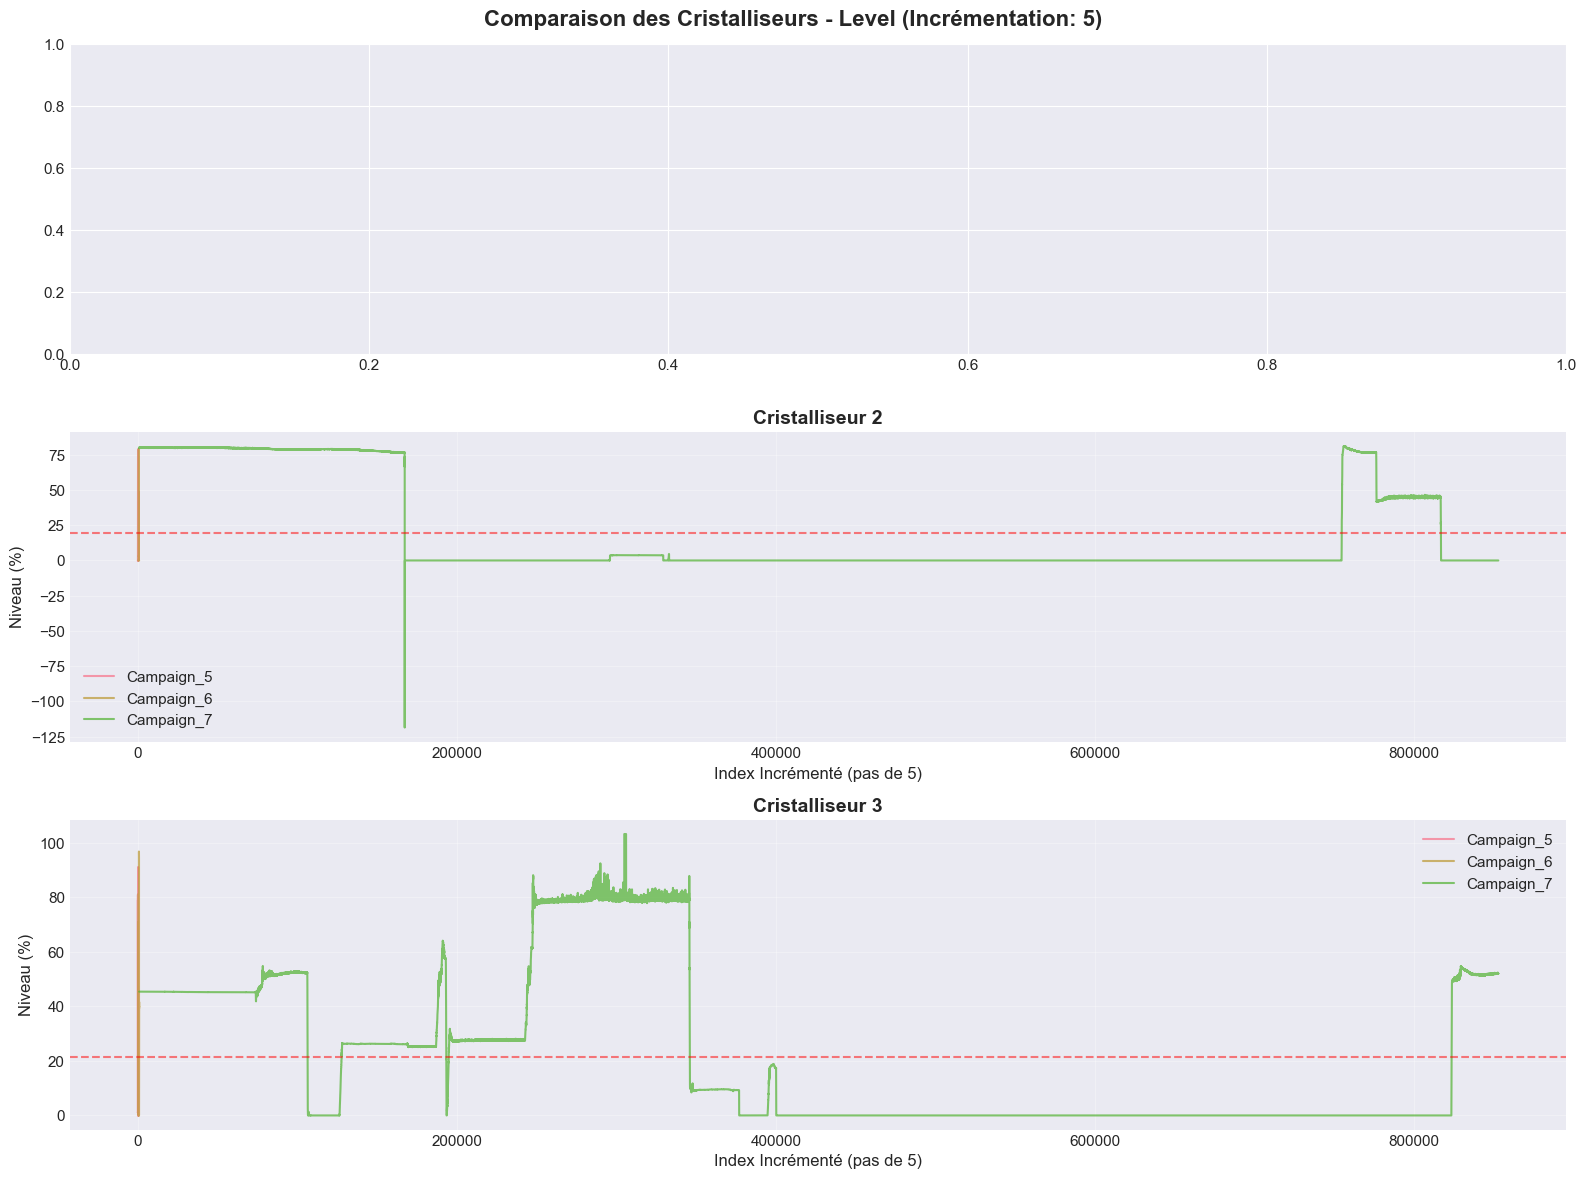

✓ Graphique sauvegardé: outputs/figures/02_comparison_level_increment_5.png


In [42]:
def plot_crystallizers_comparison_with_increment(df, increment=5, metric='temperature'):
    fig, axes = plt.subplots(3, 1, figsize=(16, 12))
    fig.suptitle(f'Comparaison des Cristalliseurs - {metric.capitalize()} (Incrémentation: {increment})', 
                 fontsize=16, fontweight='bold')
    
    if metric == 'temperature':
        cols = ['AVG_826TRC07', 'AVG_826TRC08', 'AVG_826TRC09']
        ylabel = 'Température (°C)'
        colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
    else:
        cols = ['AVG_826LR04', 'AVG_826LR05', 'AVG_826LR06']
        ylabel = 'Niveau (%)'
        colors = ['#FFA07A', '#98D8C8', '#6C5CE7']
    
    for idx, (col, color) in enumerate(zip(cols, colors)):
        if col in df.columns:
            data = df[['TIMESTAMP', col, 'CAMPAIGN']].dropna(subset=[col])
            data = data.reset_index(drop=True)
            data['INCREMENT_INDEX'] = (data.index // increment) * increment
            
            for campaign in data['CAMPAIGN'].unique():
                campaign_data = data[data['CAMPAIGN'] == campaign]
                axes[idx].plot(campaign_data['INCREMENT_INDEX'], campaign_data[col], 
                             label=campaign, alpha=0.7, linewidth=1.5)
            
            axes[idx].set_title(f'Cristalliseur {idx+1}', fontsize=14, fontweight='bold')
            axes[idx].set_xlabel(f'Index Incrémenté (pas de {increment})', fontsize=12)
            axes[idx].set_ylabel(ylabel, fontsize=12)
            axes[idx].legend(loc='best')
            axes[idx].grid(True, alpha=0.3)
            
            mean_val = data[col].mean()
            axes[idx].axhline(y=mean_val, color='red', linestyle='--', 
                            label=f'Moyenne: {mean_val:.2f}', alpha=0.5)
    
    plt.tight_layout()
    filename = f'outputs/figures/02_comparison_{metric}_increment_{increment}.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'✓ Graphique sauvegardé: {filename}')

# Comparaison des températures
plot_crystallizers_comparison_with_increment(all_campaigns, increment=5, metric='temperature')

# Comparaison des niveaux
plot_crystallizers_comparison_with_increment(all_campaigns, increment=5, metric='level')

In [45]:
def plot_crystallizers_comparison_with_increment(df, increment=5, metric='temperature'):
    fig, axes = plt.subplots(3, 1, figsize=(16, 12))
    fig.suptitle(f'Comparaison des Cristalliseurs - {metric.capitalize()} (Incrémentation: {increment})', 
                 fontsize=16, fontweight='bold')
    
    if metric == 'temperature':
        cols = ['AVG_826TRC07', 'AVG_826TRC08', 'AVG_826TRC09']
        ylabel = 'Température (°C)'
        colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
    else:
        cols = ['AVG_826LR04', 'AVG_826LR05', 'AVG_826LR06']
        ylabel = 'Niveau (%)'
        colors = ['#FFA07A', '#98D8C8', '#6C5CE7']
    
    for idx, (col, color) in enumerate(zip(cols, colors)):
        if col in df.columns:
            data = df[['TIMESTAMP', col, 'CAMPAIGN']].dropna(subset=[col])
            
            # garder uniquement campagne 5 et 6
            data = data[data['CAMPAIGN'].isin(['Campaign_5', 'Campaign_6'])]
            
            data = data.reset_index(drop=True)
            data['INCREMENT_INDEX'] = (data.index // increment) * increment
            
            for campaign in data['CAMPAIGN'].unique():
                campaign_data = data[data['CAMPAIGN'] == campaign]
                
                axes[idx].plot(
                    campaign_data['INCREMENT_INDEX'],
                    campaign_data[col],
                    label=campaign,
                    linewidth=1.5
                )
            
            axes[idx].set_title(f'Cristalliseur {idx+1}', fontsize=14, fontweight='bold')
            axes[idx].set_xlabel(f'Index Incrémenté (pas de {increment})')
            axes[idx].set_ylabel(ylabel)
            axes[idx].legend()
            axes[idx].grid(True, alpha=0.3)

            mean_val = data[col].mean()
            axes[idx].axhline(y=mean_val, color='red', linestyle='--',
                              label=f'Moyenne: {mean_val:.2f}', alpha=0.5)
    
    plt.tight_layout()
    filename = f'outputs/figures/02_comparison_{metric}_increment_{increment}.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

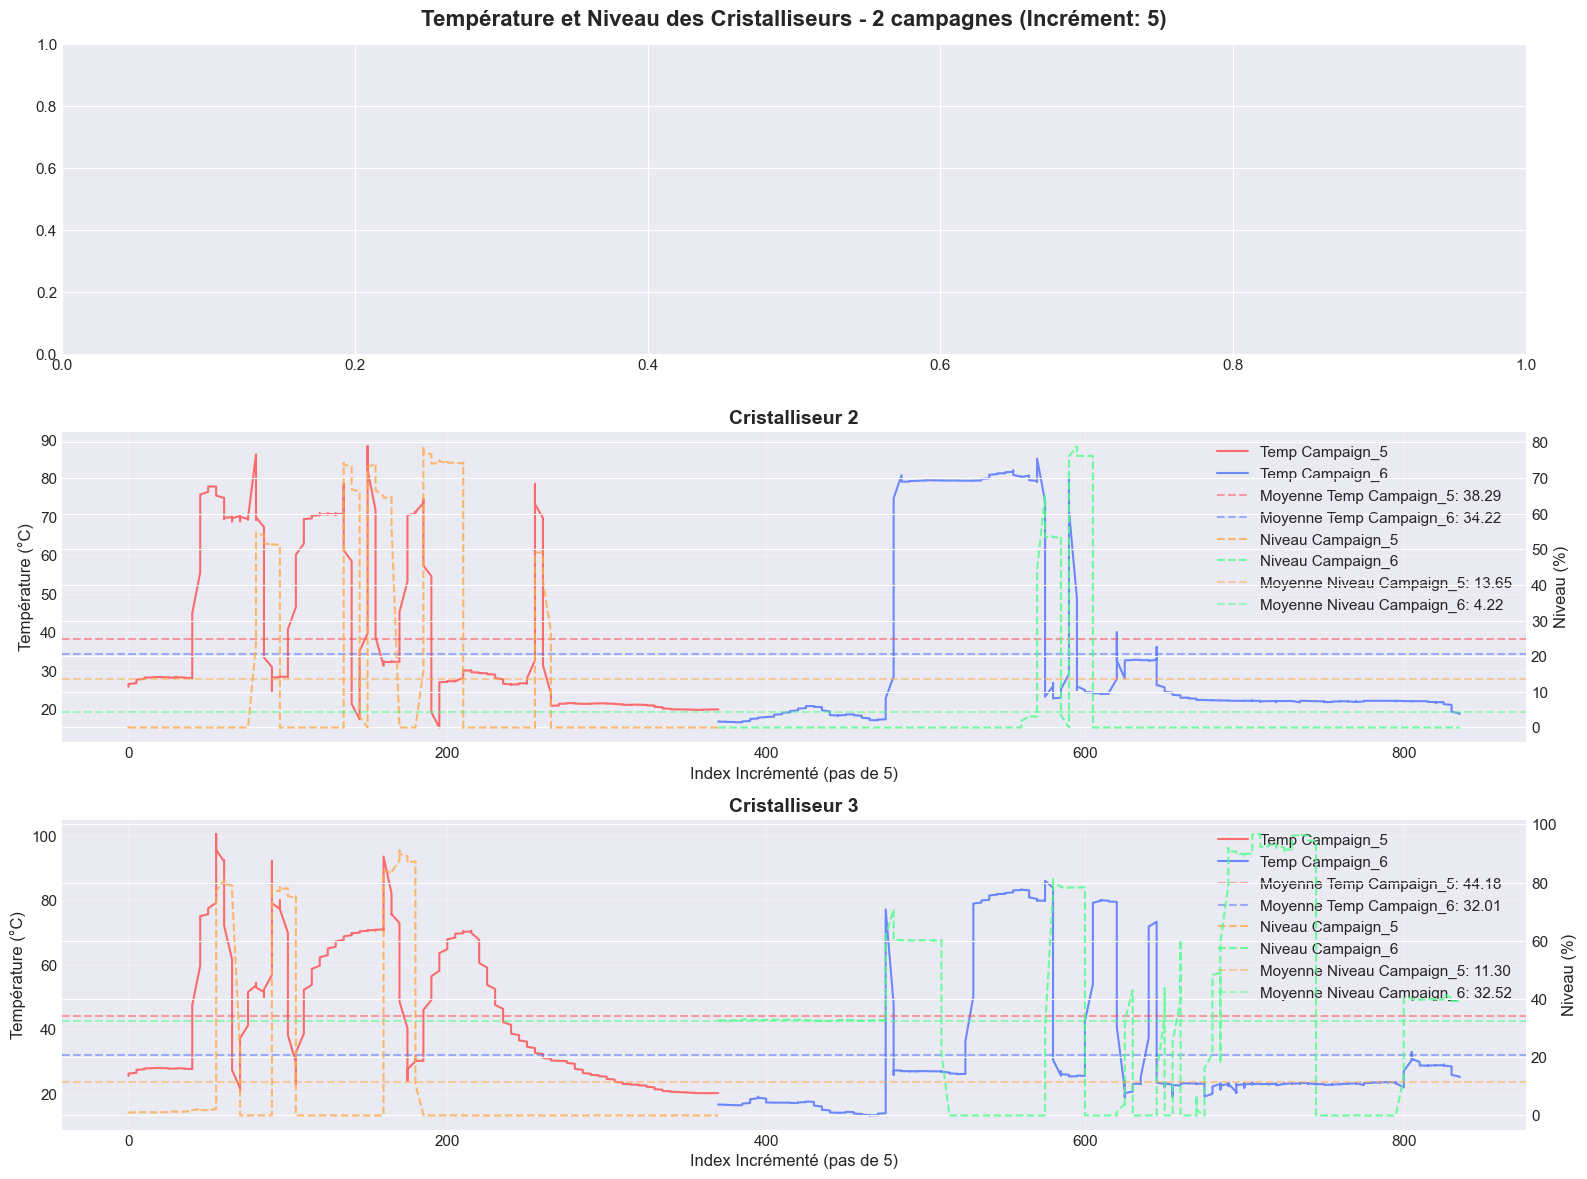

✓ Graphique sauvegardé: outputs/figures/02_comparison_temp_level_2campaigns_colors_increment_5.png


In [49]:
def plot_crystallizers_temp_and_level_two_campaigns_colored(df, increment=5):
    fig, axes = plt.subplots(3, 1, figsize=(16, 12))
    fig.suptitle(f'Température et Niveau des Cristalliseurs - 2 campagnes (Incrément: {increment})', 
                 fontsize=16, fontweight='bold')
    
    temp_cols = ['AVG_826TRC07', 'AVG_826TRC08', 'AVG_826TRC09']
    level_cols = ['AVG_826LR04', 'AVG_826LR05', 'AVG_826LR06']
    
    # Couleurs par campagne
    temp_colors = {'Campaign_5': '#FF4C4C', 'Campaign_6': '#4C6EFF'}  # rouge / bleu
    level_colors = {'Campaign_5': '#FFAA4C', 'Campaign_6': '#4CFF88'}  # orange / vert
    
    for idx in range(3):
        temp_col = temp_cols[idx]
        level_col = level_cols[idx]
        
        if temp_col in df.columns and level_col in df.columns:
            data = df[['TIMESTAMP', temp_col, level_col, 'CAMPAIGN']].dropna(subset=[temp_col, level_col])
            
            # Ne garder que les deux campagnes
            data = data[data['CAMPAIGN'].isin(['Campaign_5', 'Campaign_6'])]
            
            data = data.reset_index(drop=True)
            data['INCREMENT_INDEX'] = (data.index // increment) * increment
            
            ax1 = axes[idx]
            ax2 = ax1.twinx()
            
            for campaign in ['Campaign_5', 'Campaign_6']:
                campaign_data = data[data['CAMPAIGN'] == campaign]
                
                # Tracé température
                ax1.plot(campaign_data['INCREMENT_INDEX'], campaign_data[temp_col], 
                         label=f'Temp {campaign}', color=temp_colors[campaign], alpha=0.8, linewidth=1.5)
                # Tracé niveau
                ax2.plot(campaign_data['INCREMENT_INDEX'], campaign_data[level_col], 
                         label=f'Niveau {campaign}', color=level_colors[campaign], alpha=0.8, linestyle='--', linewidth=1.5)
            
            ax1.set_title(f'Cristalliseur {idx+1}', fontsize=14, fontweight='bold')
            ax1.set_xlabel(f'Index Incrémenté (pas de {increment})', fontsize=12)
            ax1.set_ylabel('Température (°C)', fontsize=12)
            ax2.set_ylabel('Niveau (%)', fontsize=12)
            
            ax1.grid(True, alpha=0.3)
            
            # Moyennes
            for campaign in ['Campaign_5', 'Campaign_6']:
                if not data[data['CAMPAIGN'] == campaign].empty:
                    ax1.axhline(data[data['CAMPAIGN'] == campaign][temp_col].mean(), 
                                color=temp_colors[campaign], linestyle='--', alpha=0.5,
                                label=f'Moyenne Temp {campaign}: {data[data["CAMPAIGN"] == campaign][temp_col].mean():.2f}')
                    ax2.axhline(data[data['CAMPAIGN'] == campaign][level_col].mean(), 
                                color=level_colors[campaign], linestyle='--', alpha=0.5,
                                label=f'Moyenne Niveau {campaign}: {data[data["CAMPAIGN"] == campaign][level_col].mean():.2f}')
            
            # Légendes combinées
            lines, labels = ax1.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            ax1.legend(lines + lines2, labels + labels2, loc='best')
    
    plt.tight_layout()
    filename = f'outputs/figures/02_comparison_temp_level_2campaigns_colors_increment_{increment}.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'✓ Graphique sauvegardé: {filename}')

# Appel de la fonction
plot_crystallizers_temp_and_level_two_campaigns_colored(all_campaigns, increment=5)

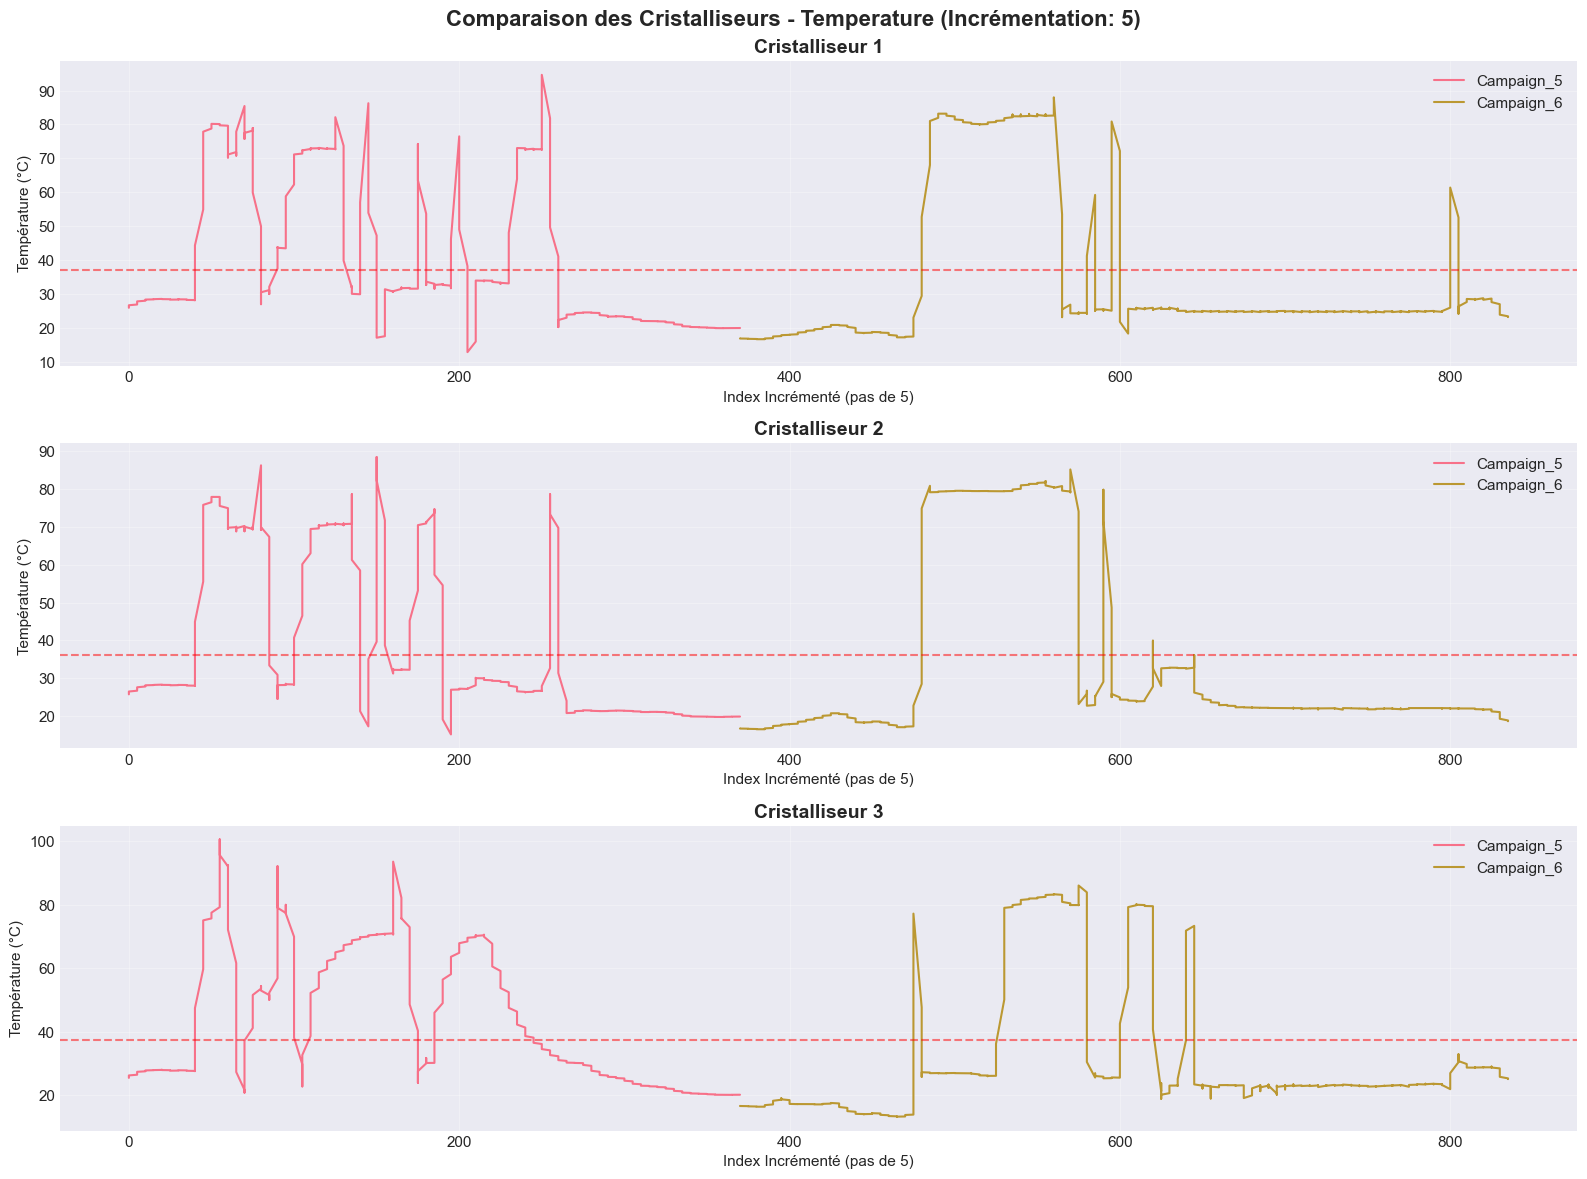

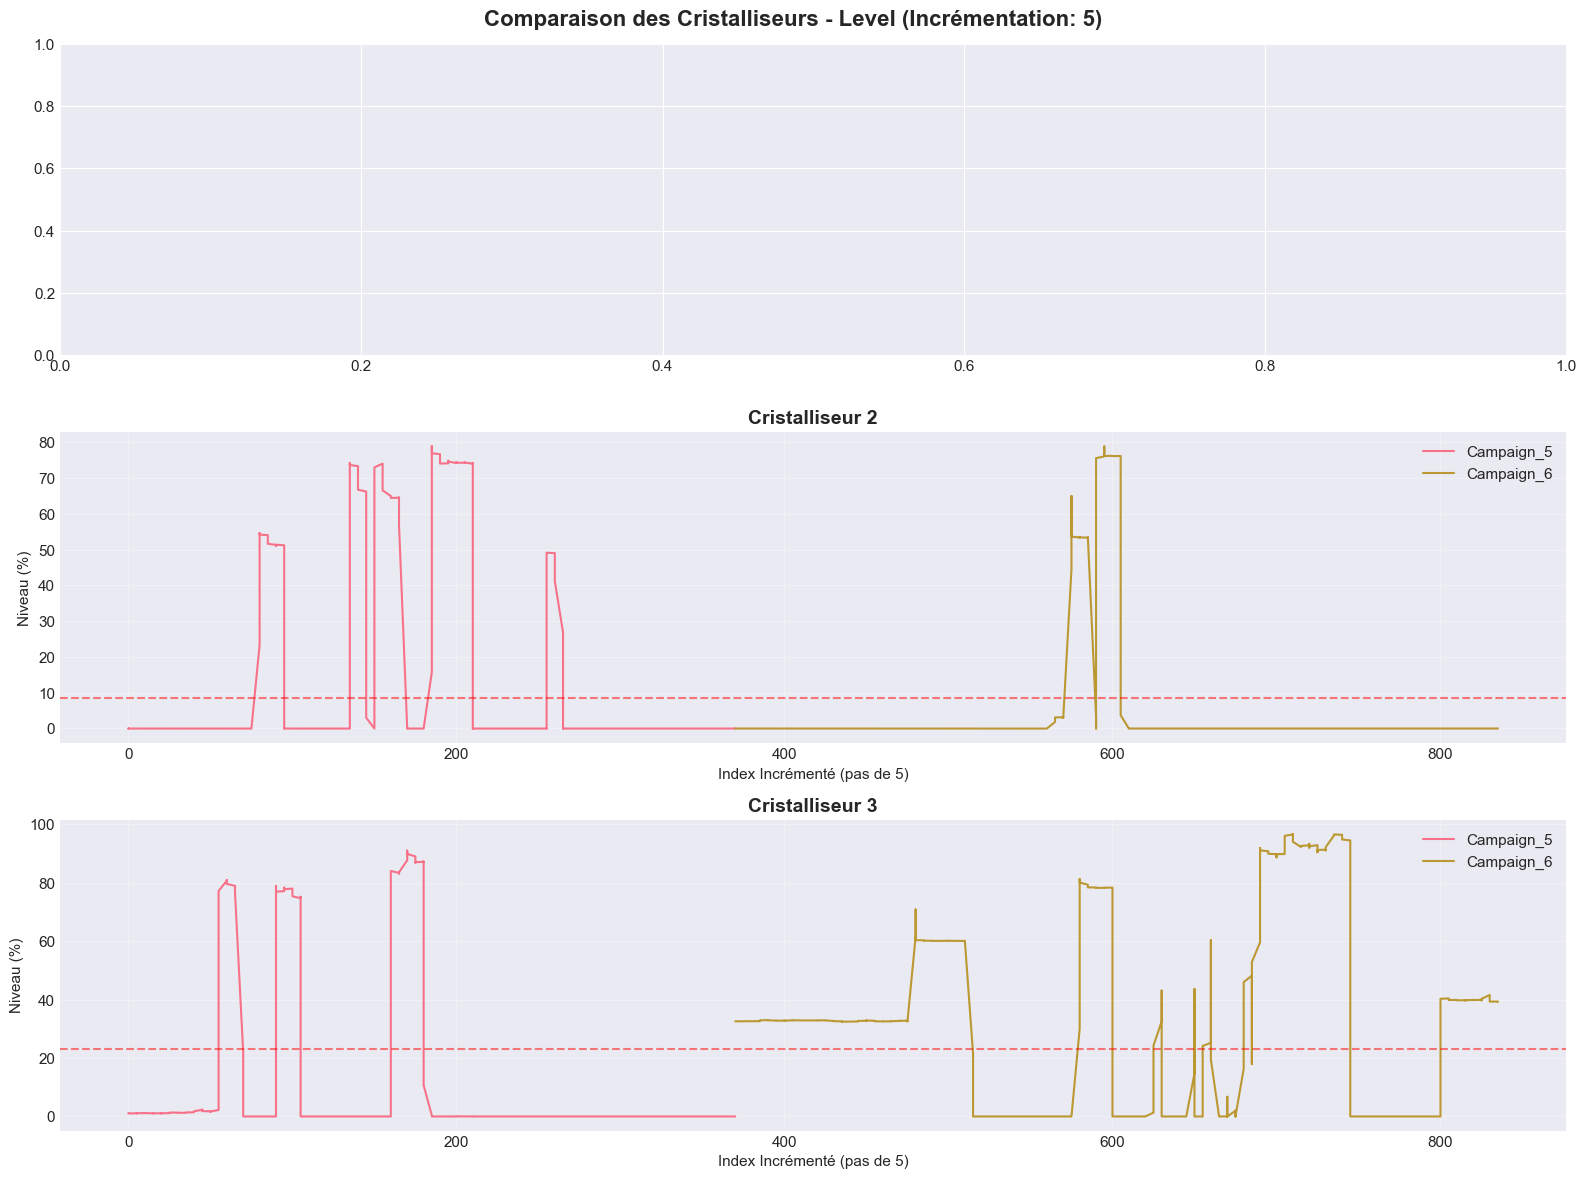

In [46]:
# Comparaison des températures
plot_crystallizers_comparison_with_increment(all_campaigns, increment=5, metric='temperature')

# Comparaison des niveaux
plot_crystallizers_comparison_with_increment(all_campaigns, increment=5, metric='level')

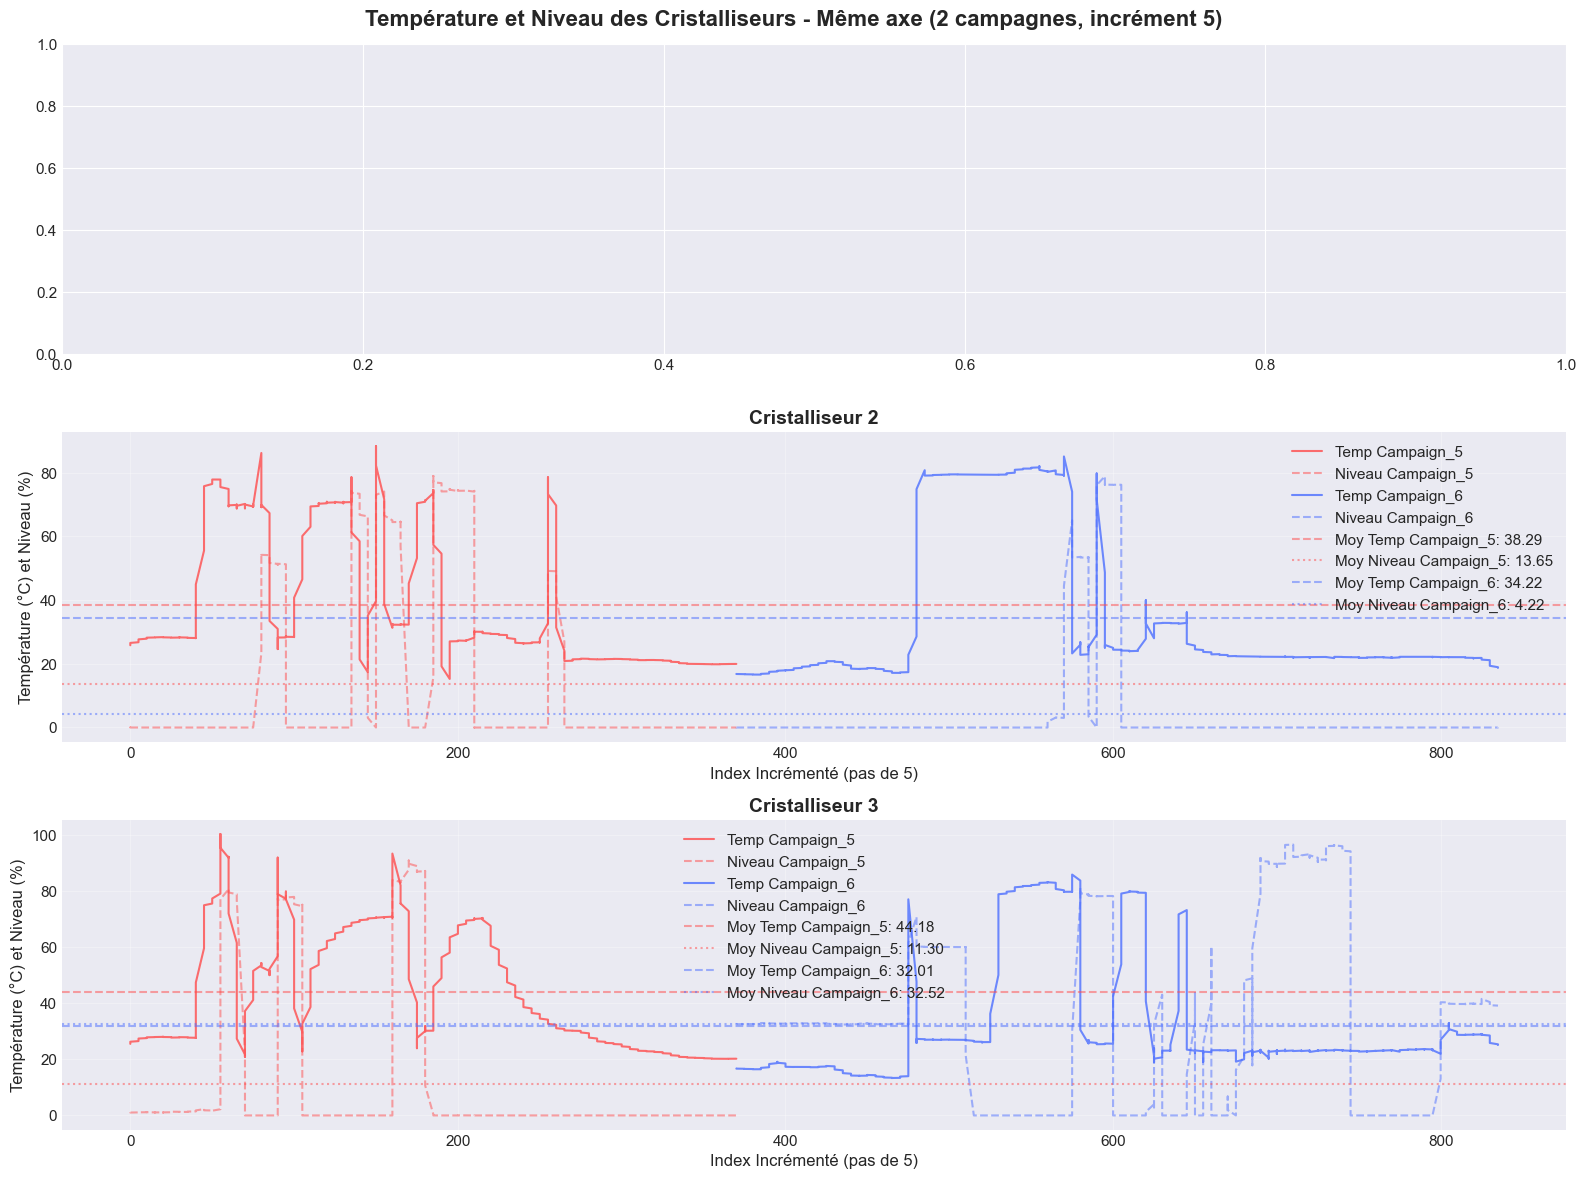

✓ Graphique sauvegardé: outputs/figures/02_comparison_temp_level_same_axis_2campaigns_increment_5.png


In [52]:
def plot_crystallizers_temp_and_level_same_axis(df, increment=5):
    fig, axes = plt.subplots(3, 1, figsize=(16, 12))
    fig.suptitle(f'Température et Niveau des Cristalliseurs - Même axe (2 campagnes, incrément {increment})', 
                 fontsize=16, fontweight='bold')
    
    temp_cols = ['AVG_826TRC07', 'AVG_826TRC08', 'AVG_826TRC09']
    level_cols = ['AVG_826LR04', 'AVG_826LR05', 'AVG_826LR06']
    
    # Couleurs par campagne
    colors = {'Campaign_5': '#FF4C4C', 'Campaign_6': '#4C6EFF'}  # rouge / bleu
    
    for idx in range(3):
        temp_col = temp_cols[idx]
        level_col = level_cols[idx]
        
        if temp_col in df.columns and level_col in df.columns:
            data = df[['TIMESTAMP', temp_col, level_col, 'CAMPAIGN']].dropna(subset=[temp_col, level_col])
            
            # Ne garder que les deux campagnes
            data = data[data['CAMPAIGN'].isin(['Campaign_5', 'Campaign_6'])]
            
            data = data.reset_index(drop=True)
            data['INCREMENT_INDEX'] = (data.index // increment) * increment
            
            ax = axes[idx]
            
            for campaign in ['Campaign_5', 'Campaign_6']:
                campaign_data = data[data['CAMPAIGN'] == campaign]
                
                # Tracé température
                ax.plot(campaign_data['INCREMENT_INDEX'], campaign_data[temp_col], 
                        label=f'Temp {campaign}', color=colors[campaign], alpha=0.8, linewidth=1.5)
                # Tracé niveau
                ax.plot(campaign_data['INCREMENT_INDEX'], campaign_data[level_col], 
                        label=f'Niveau {campaign}', color=colors[campaign], alpha=0.5, linestyle='--', linewidth=1.5)
            
            ax.set_title(f'Cristalliseur {idx+1}', fontsize=14, fontweight='bold')
            ax.set_xlabel(f'Index Incrémenté (pas de {increment})', fontsize=12)
            ax.set_ylabel('Température (°C) et Niveau (%)', fontsize=12)
            ax.grid(True, alpha=0.3)
            
            # Moyennes
            for campaign in ['Campaign_5', 'Campaign_6']:
                if not data[data['CAMPAIGN'] == campaign].empty:
                    ax.axhline(data[data['CAMPAIGN'] == campaign][temp_col].mean(), 
                               color=colors[campaign], linestyle='--', alpha=0.5,
                               label=f'Moy Temp {campaign}: {data[data["CAMPAIGN"] == campaign][temp_col].mean():.2f}')
                    ax.axhline(data[data['CAMPAIGN'] == campaign][level_col].mean(), 
                               color=colors[campaign], linestyle=':', alpha=0.5,
                               label=f'Moy Niveau {campaign}: {data[data["CAMPAIGN"] == campaign][level_col].mean():.2f}')
            
            ax.legend(loc='best')
    
    plt.tight_layout()
    filename = f'outputs/figures/02_comparison_temp_level_same_axis_2campaigns_increment_{increment}.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'✓ Graphique sauvegardé: {filename}')

# Appel de la fonction
plot_crystallizers_temp_and_level_same_axis(all_campaigns, increment=5)

---
## 6. Clustering et Segmentation

In [35]:
# Préparation des données pour le clustering
clustering_features = [
    'AVG_826TRC07', 'AVG_826TRC08', 'AVG_826TRC09',
    'AVG_826LR04', 'AVG_826LR05', 'AVG_826LR06',
    'AVG_826TRC07_DELTAT', 'AVG_826TRC08_DELTAT', 'AVG_826TRC09_DELTAT',
    'AVG_826FQR23'
]

available_features = [col for col in clustering_features if col in all_campaigns.columns]
print(f'Features disponibles: {len(available_features)}')

clustering_data = all_campaigns[available_features + ['TIMESTAMP', 'CAMPAIGN']].dropna()
print(f'Nombre de lignes pour le clustering: {len(clustering_data)}')

# Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(clustering_data[available_features])
print('✓ Données normalisées')

Features disponibles: 9
Nombre de lignes pour le clustering: 837
✓ Données normalisées


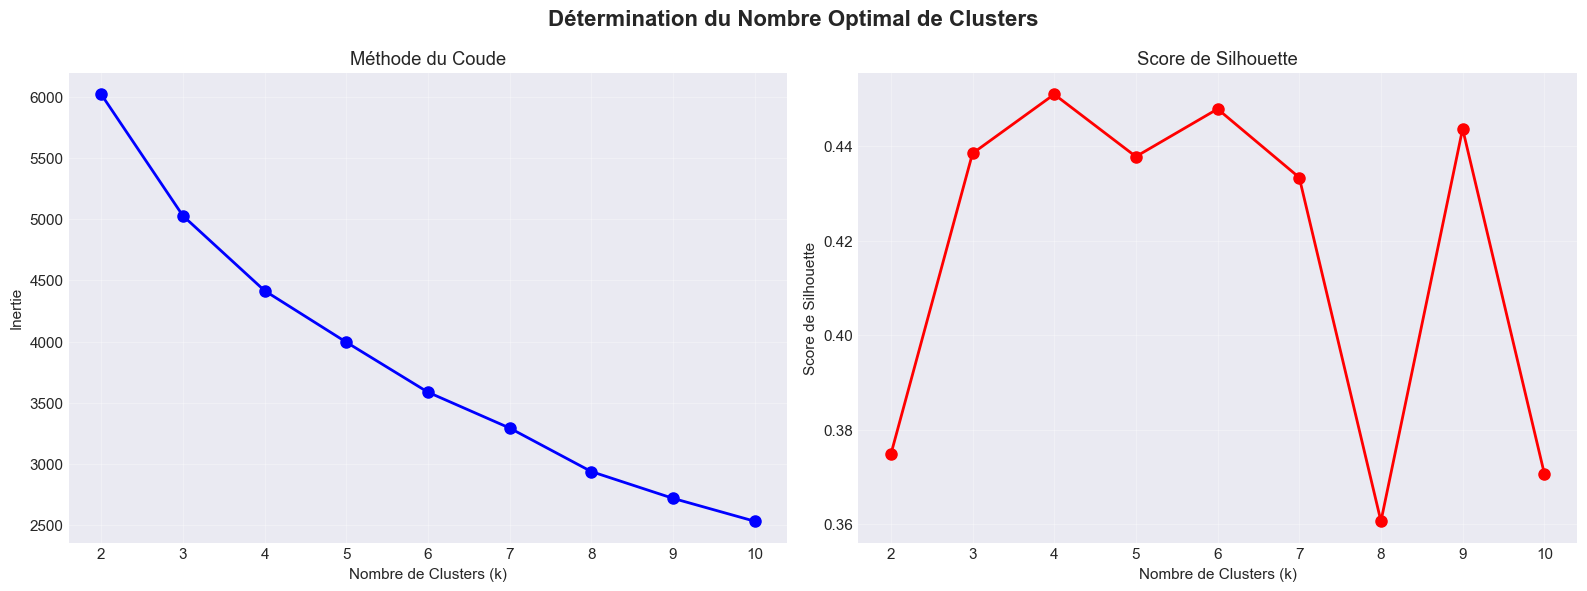


✓ Nombre optimal de clusters: 4
✓ Score de silhouette maximal: 0.451


In [36]:
# Détermination du nombre optimal de clusters
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Détermination du Nombre Optimal de Clusters', fontsize=16, fontweight='bold')

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Nombre de Clusters (k)')
axes[0].set_ylabel('Inertie')
axes[0].set_title('Méthode du Coude')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Nombre de Clusters (k)')
axes[1].set_ylabel('Score de Silhouette')
axes[1].set_title('Score de Silhouette')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/figures/04_optimal_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

best_k = K_range[np.argmax(silhouette_scores)]
print(f'\n✓ Nombre optimal de clusters: {best_k}')
print(f'✓ Score de silhouette maximal: {max(silhouette_scores):.3f}')

In [37]:
# Application du K-Means
optimal_k = best_k
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clustering_data['Cluster'] = kmeans.fit_predict(X_scaled)

print(f'=== Résultats du Clustering (k={optimal_k}) ===')
print('\nRépartition des clusters:')
print(clustering_data['Cluster'].value_counts().sort_index())

print('\n=== Caractéristiques Moyennes par Cluster ===')
cluster_stats = clustering_data.groupby('Cluster')[available_features].mean()
display(cluster_stats)

=== Résultats du Clustering (k=4) ===

Répartition des clusters:
Cluster
0    521
1     21
2    198
3     97
Name: count, dtype: int64

=== Caractéristiques Moyennes par Cluster ===


,AVG_826TRC07,AVG_826TRC08,AVG_826TRC09,AVG_826LR05,AVG_826LR06,AVG_826TRC07_DELTAT,AVG_826TRC08_DELTAT,AVG_826TRC09_DELTAT,AVG_826FQR23
Cluster,,,,,,,,,
0,24.273623,22.864655,26.960505,0.034007,23.309062,0.000943,0.001657,-0.004183,-6.466129
1,47.157154,53.628504,54.235368,32.458201,31.586734,0.283512,0.146598,0.033715,1078.632279
2,71.734703,67.122873,53.251734,0.262357,21.860839,-0.013635,0.013926,0.003226,-24.997214
3,34.655885,39.518384,57.762413,64.938023,22.349572,-0.036864,-0.069636,0.003394,-7.143190


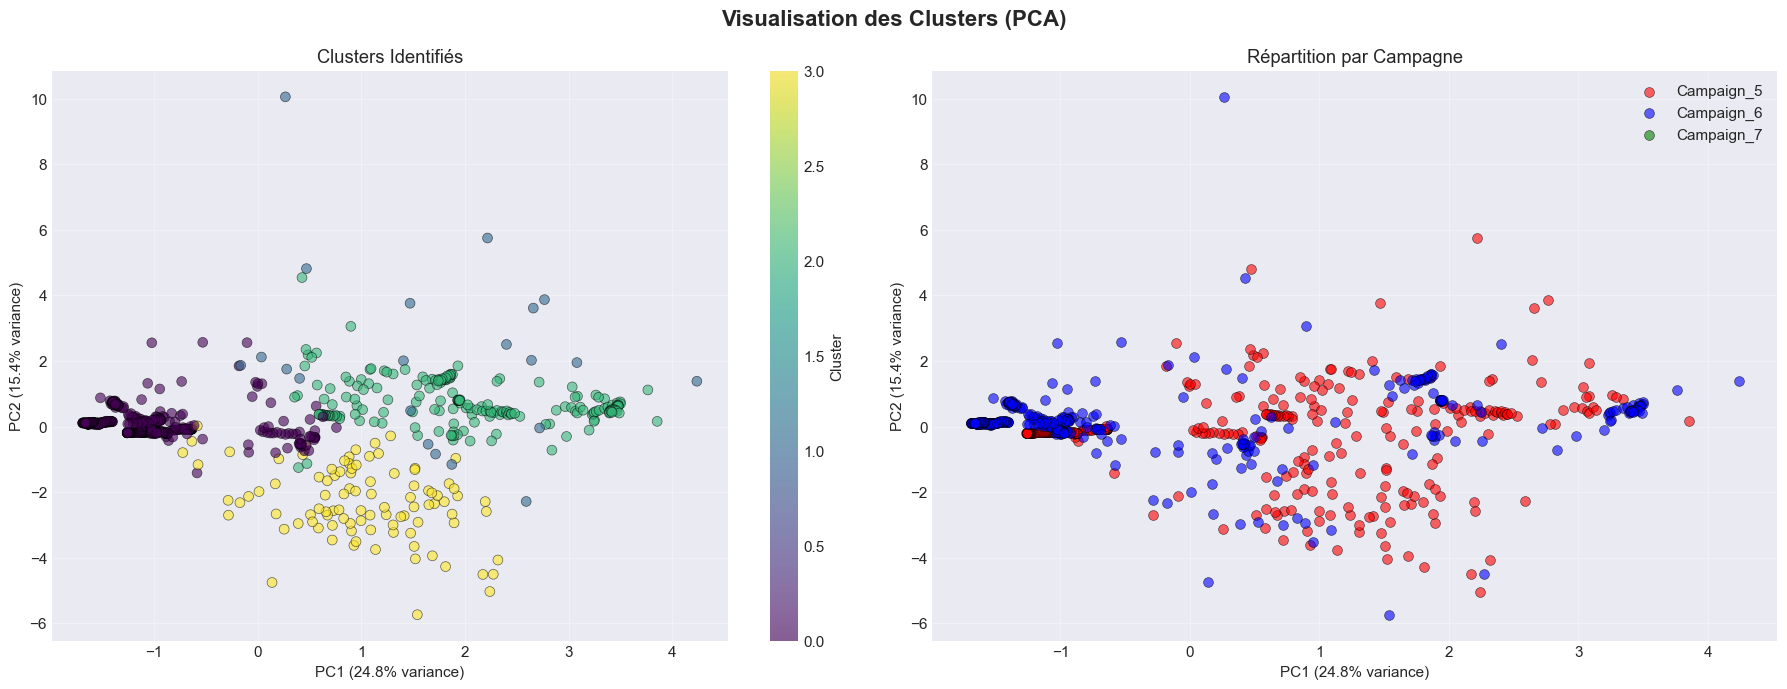

✓ Variance totale expliquée: 40.3%


In [38]:
# Visualisation avec PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Visualisation des Clusters (PCA)', fontsize=16, fontweight='bold')

# Par cluster
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=clustering_data['Cluster'], 
                          cmap='viridis', alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[0].set_title('Clusters Identifiés')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Par campagne
campaign_colors = {'Campaign_5': 'red', 'Campaign_6': 'blue', 'Campaign_7': 'green'}
for campaign, color in campaign_colors.items():
    mask = clustering_data['CAMPAIGN'] == campaign
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=campaign, 
                   alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[1].set_title('Répartition par Campagne')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/figures/05_clustering_pca.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'✓ Variance totale expliquée: {sum(pca.explained_variance_ratio_):.1%}')

---
## 7. Visualisations Avancées

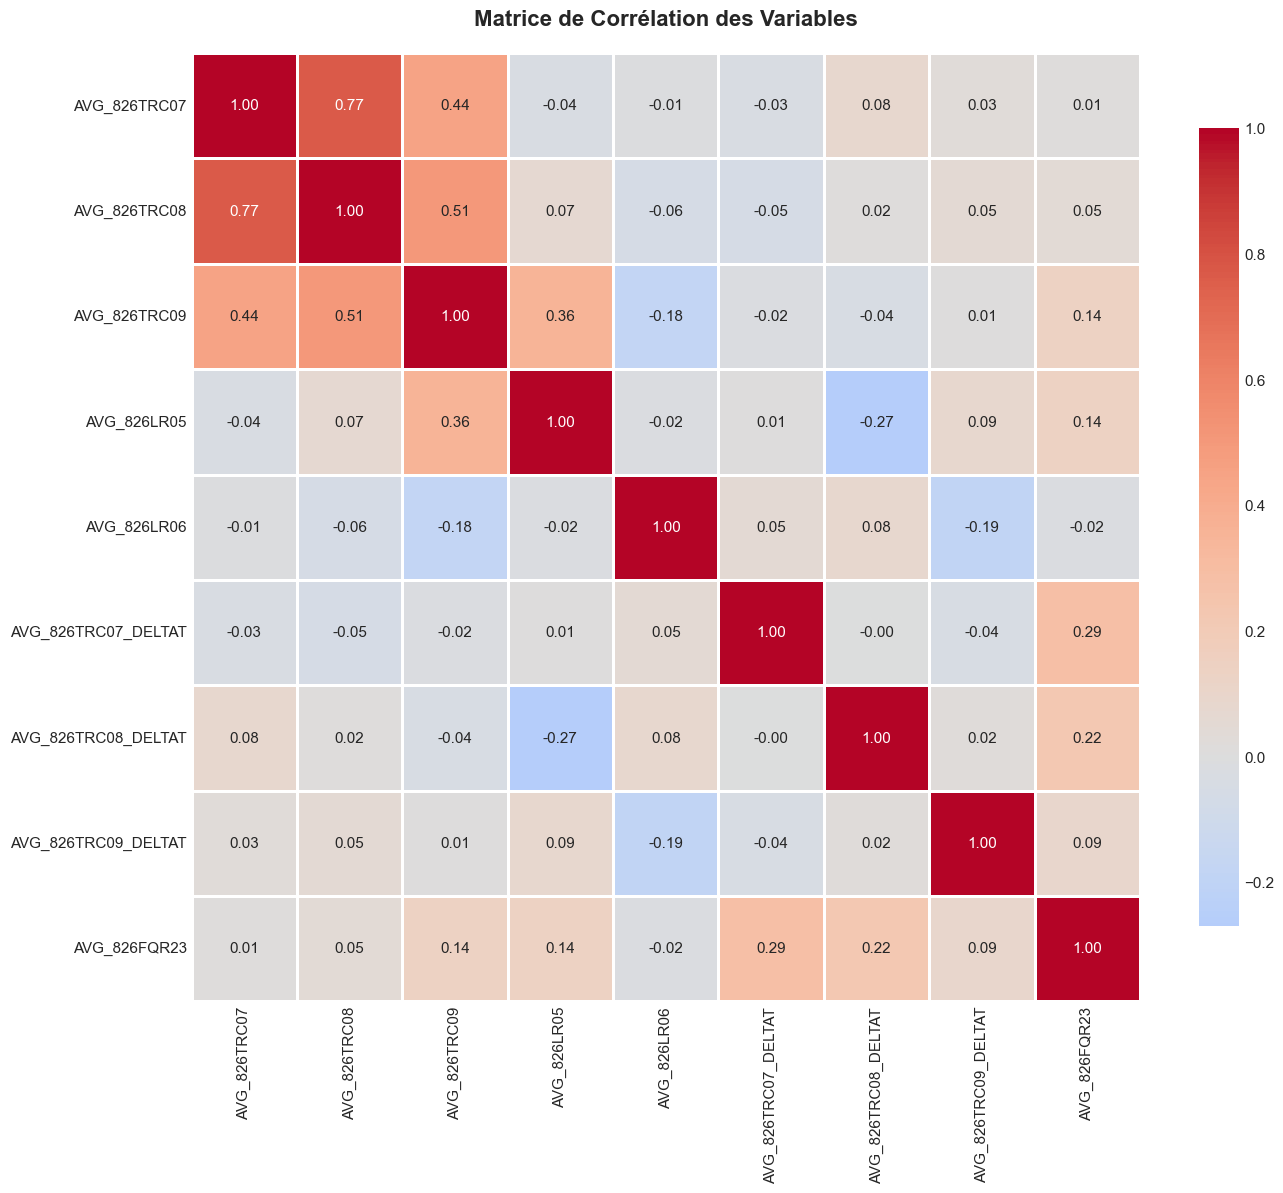

✓ Graphique sauvegardé


In [39]:
# Heatmap de corrélation
correlation_matrix = clustering_data[available_features].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={'shrink': 0.8})
plt.title('Matrice de Corrélation des Variables', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('outputs/figures/06_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Graphique sauvegardé')